# 02 — Naive False-Data Injection

本节对单个量测进行透明的加性篡改，并观察状态估计和残差统计量的变化。

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
from src.grid_model import build_three_bus_model, generate_measurement
from src.state_estimator import wls_estimate
from src.attack_generator import naive_attack

rng = np.random.default_rng(42)
model = build_three_bus_model(sigma=0.01)

z, _ = generate_measurement(model, rng)
normal = wls_estimate(z, model.H, model.R)

z_attack, a = naive_attack(z, measurement_index=0, magnitude=0.10)
attacked = wls_estimate(z_attack, model.H, model.R)

print("Attack vector a =", a)
print("Normal x_hat =", normal.x_hat)
print("Attacked x_hat =", attacked.x_hat)
print("Normal J =", normal.J)
print("Attacked J =", attacked.J)


Attack vector a = [0.1 0.  0.  0.  0. ]
Normal x_hat = [-0.03988588 -0.06093575]
Attacked x_hat = [-0.04389085 -0.06481634]
Normal J = 2.8710337100468237
Attacked J = 71.1980961744731


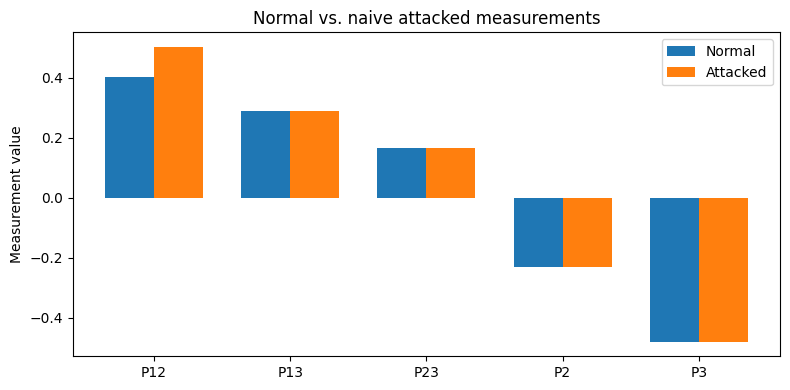

In [3]:
labels = list(model.measurement_names)
x = np.arange(len(labels))

plt.figure(figsize=(8, 4))
plt.bar(x - 0.18, z, width=0.36, label="Normal")
plt.bar(x + 0.18, z_attack, width=0.36, label="Attacked")
plt.xticks(x, labels)
plt.ylabel("Measurement value")
plt.title("Normal vs. naive attacked measurements")
plt.legend()
plt.tight_layout()
plt.show()


### 课堂任务

把 `measurement_index` 从 0 改为 1–4，比较不同量测位置被篡改时的 `J`。